In [40]:

# get datatypes in df
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264835 entries, 0 to 264834
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264835 non-null  datetime64[ns]
 1   STORE_NBR         264835 non-null  int64         
 2   LYLTY_CARD_NBR    264835 non-null  int64         
 3   TXN_ID            264835 non-null  int64         
 4   PROD_NBR          264835 non-null  object        
 5   PROD_NAME         264835 non-null  object        
 6   PROD_QTY          264835 non-null  int64         
 7   TOT_SALES         264835 non-null  float64       
 8   prod_name_lower   264835 non-null  object        
 9   ends_with_weight  264835 non-null  bool          
 10  WEIGHT            264835 non-null  int64         
 11  LIFESTAGE         264835 non-null  object        
 12  PREMIUM_CUSTOMER  264835 non-null  object        
 13  BRAND             264835 non-null  object        
dtypes: b

In [41]:
import pandas as pd
import numpy as np

df['YEARMONTH'] = df['DATE'].dt.strftime('%Y%m')

store_monthly = (
    df.groupby(['STORE_NBR','YEARMONTH'])
      .agg(
          TOT_SALES=('TOT_SALES','sum'),
          N_CUSTOMERS=('LYLTY_CARD_NBR','nunique'),
          N_TXNS=('TXN_ID','nunique')
      )
      .reset_index()
)

store_monthly['TXN_PER_CUSTOMER'] = (
    store_monthly['N_TXNS'] /
    store_monthly['N_CUSTOMERS']
)

print(store_monthly.head())
print(store_monthly.shape)

   STORE_NBR YEARMONTH  TOT_SALES  N_CUSTOMERS  N_TXNS  TXN_PER_CUSTOMER
0          1    201807      206.9           49      52          1.061224
1          1    201808      176.1           42      43          1.023810
2          1    201809      278.8           59      62          1.050847
3          1    201810      188.1           44      45          1.022727
4          1    201811      192.6           46      47          1.021739
(3169, 6)


In [42]:
store_counts = (
    store_monthly.groupby('STORE_NBR')['YEARMONTH']
    .nunique()
    .sort_values()
)

print(store_counts.value_counts())

YEARMONTH
12    260
2       5
1       3
11      3
3       1
Name: count, dtype: int64


In [43]:
pretrial = store_monthly[
    store_monthly['YEARMONTH'] < '201902'
].copy()

print(pretrial['YEARMONTH'].unique())

['201807' '201808' '201809' '201810' '201811' '201812' '201901']


In [44]:
def calculate_correlation(input_table,
                          metric_col,
                          trial_store):

    trial_data = input_table[
        input_table['STORE_NBR'] == trial_store
    ][['YEARMONTH', metric_col]]

    correlations = []

    for store in input_table['STORE_NBR'].unique():

        if store == trial_store:
            continue

        control = input_table[
            input_table['STORE_NBR'] == store
        ][['YEARMONTH', metric_col]]

        merged = trial_data.merge(
            control,
            on='YEARMONTH',
            suffixes=('_trial','_control')
        )

        corr = merged[
            f'{metric_col}_trial'
        ].corr(
            merged[f'{metric_col}_control']
        )

        correlations.append(
            [trial_store, store, corr]
        )

    return pd.DataFrame(
        correlations,
        columns=[
            'TRIAL_STORE',
            'CONTROL_STORE',
            'CORRELATION'
        ]
    )

In [45]:
def calculate_magnitude_distance(
        input_table,
        metric_col,
        trial_store):

    trial = input_table[
        input_table['STORE_NBR']==trial_store
    ][['YEARMONTH',metric_col]]

    scores = []

    for store in input_table['STORE_NBR'].unique():

        if store == trial_store:
            continue

        control = input_table[
            input_table['STORE_NBR']==store
        ][['YEARMONTH',metric_col]]

        merged = trial.merge(
            control,
            on='YEARMONTH',
            suffixes=('_trial','_control')
        )

        distance = abs(
            merged[f'{metric_col}_trial']
            -
            merged[f'{metric_col}_control']
        )

        score = 1 - (
            (distance - distance.min()) /
            (distance.max() - distance.min() + 1e-9)
        )

        scores.append([
            trial_store,
            store,
            score.mean()
        ])

    return pd.DataFrame(
        scores,
        columns=[
            'TRIAL_STORE',
            'CONTROL_STORE',
            'MAG_SCORE'
        ]
    )

In [46]:
trial_stores = [77,86,88]

for trial in trial_stores:

    sales_corr = calculate_correlation(
        pretrial,
        'TOT_SALES',
        trial
    )

    sales_mag = calculate_magnitude_distance(
        pretrial,
        'TOT_SALES',
        trial
    )

    customer_corr = calculate_correlation(
        pretrial,
        'N_CUSTOMERS',
        trial
    )

    customer_mag = calculate_magnitude_distance(
        pretrial,
        'N_CUSTOMERS',
        trial
    )

    combined = (
        sales_corr
        .merge(
            sales_mag,
            on=['TRIAL_STORE','CONTROL_STORE']
        )
        .merge(
            customer_corr.rename(
                columns={
                    'CORRELATION':
                    'CUSTOMER_CORR'
                }
            ),
            on=['TRIAL_STORE','CONTROL_STORE']
        )
        .merge(
            customer_mag.rename(
                columns={
                    'MAG_SCORE':
                    'CUSTOMER_MAG'
                }
            ),
            on=['TRIAL_STORE','CONTROL_STORE']
        )
    )

    combined['FINAL_SCORE'] = (
        combined['CORRELATION']
        +
        combined['MAG_SCORE']
        +
        combined['CUSTOMER_CORR']
        +
        combined['CUSTOMER_MAG']
    ) / 4

    print(f"\nTRIAL STORE {trial}")
    print(
        combined
        .sort_values(
            'FINAL_SCORE',
            ascending=False
        )
        .head(10)
    )

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\sit


TRIAL STORE 77
     TRIAL_STORE  CONTROL_STORE  CORRELATION  MAG_SCORE  CUSTOMER_CORR  \
230           77            233     0.903774   0.490806       0.990358   
70            77             71     0.914106   0.664887       0.754817   
82            77             84     0.684348   0.629596       0.858571   
116           77            119     0.867664   0.404428       0.983267   
112           77            115     0.689159   0.727536       0.718882   
49            77             50     0.763866   0.630361       0.607391   
2             77              3     0.806644   0.522914       0.834207   
40            77             41     0.783232   0.491685       0.844219   
262           77            265     0.639759   0.678571       0.573460   
16            77             17     0.842668   0.409456       0.747308   

     CUSTOMER_MAG  FINAL_SCORE  
230      0.642857     0.756949  
70       0.571429     0.726310  
82       0.571429     0.685986  
116      0.476190     0.682887  
112 

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\sit


TRIAL STORE 86
     TRIAL_STORE  CONTROL_STORE  CORRELATION  MAG_SCORE  CUSTOMER_CORR  \
152           86            155     0.877882   0.738330       0.942876   
106           86            109     0.788300   0.605940       0.770778   
111           86            114     0.734415   0.528371       0.855339   
222           86            225     0.617533   0.586150       0.733791   
135           86            138     0.759864   0.426729       0.749701   
237           86            240     0.825066   0.409573       0.576403   
178           86            181     0.607657   0.571478       0.549331   
257           86            260     0.720350   0.397129       0.846502   
219           86            222     0.795075   0.541590       0.458238   
191           86            194     0.476578   0.684092       0.559963   

     CUSTOMER_MAG  FINAL_SCORE  
152      0.523810     0.770724  
106      0.714286     0.719826  
111      0.471429     0.647389  
222      0.634921     0.643099  
135 

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\sit


TRIAL STORE 88
     TRIAL_STORE  CONTROL_STORE  CORRELATION  MAG_SCORE  CUSTOMER_CORR  \
175           88            178     0.731857   0.569749       0.939466   
13            88             14     0.698557   0.593571       0.942976   
131           88            134     0.864293   0.685875       0.508880   
234           88            237     0.308479   0.595469       0.947326   
184           88            187     0.599076   0.634428       0.671264   
250           88            253     0.811838   0.521990       0.500962   
34            88             35     0.150801   0.654197       0.899594   
201           88            204     0.885774   0.509249       0.550263   
68            88             69     0.450029   0.464062       0.815792   
40            88             41     0.290319   0.562729       0.721650   

     CUSTOMER_MAG  FINAL_SCORE  
175      0.476190     0.679316  
13       0.428571     0.665919  
131      0.571429     0.657619  
234      0.607143     0.614604  
184 

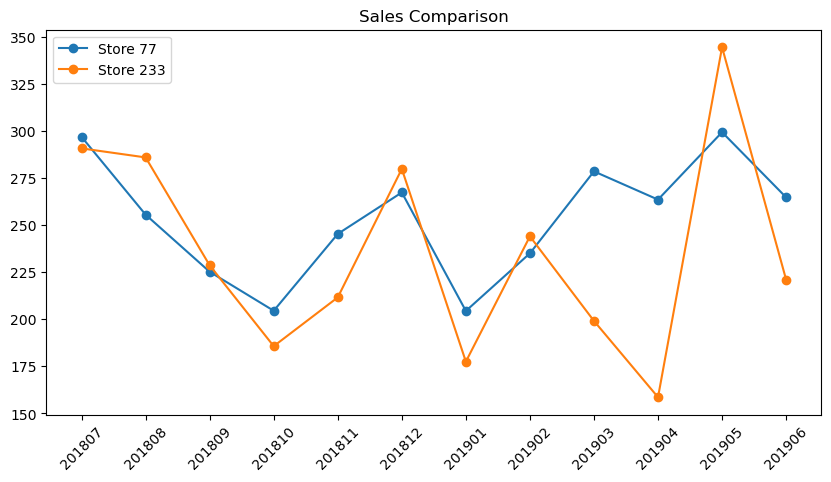

In [47]:
trial_store = 77
control_store = 233  # replace

plot_df = store_monthly[
    store_monthly['STORE_NBR'].isin(
        [trial_store, control_store]
    )
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:

    subset = plot_df[
        plot_df['STORE_NBR']==store
    ]

    plt.plot(
        subset['YEARMONTH'],
        subset['TOT_SALES'],
        marker='o',
        label=f'Store {store}'
    )

plt.legend()
plt.xticks(rotation=45)
plt.title("Sales Comparison")
plt.show()

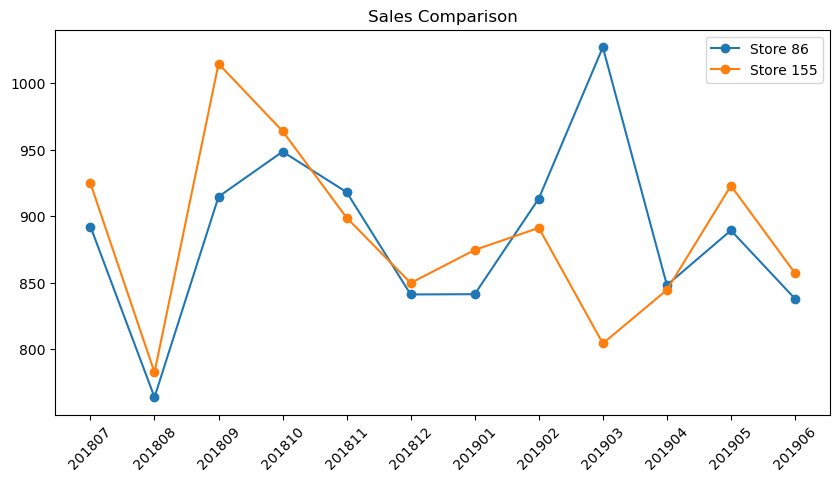

In [51]:
trial_store = 86
control_store = 155  # replace

plot_df = store_monthly[
    store_monthly['STORE_NBR'].isin(
        [trial_store, control_store]
    )
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:

    subset = plot_df[
        plot_df['STORE_NBR']==store
    ]

    plt.plot(
        subset['YEARMONTH'],
        subset['TOT_SALES'],
        marker='o',
        label=f'Store {store}'
    )

plt.legend()
plt.xticks(rotation=45)
plt.title("Sales Comparison")
plt.show()

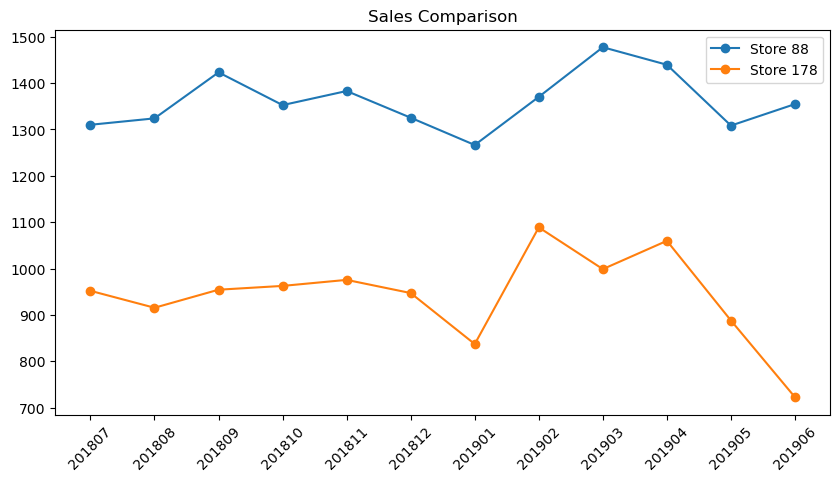

In [52]:
trial_store = 88
control_store = 178  # replace

plot_df = store_monthly[
    store_monthly['STORE_NBR'].isin(
        [trial_store, control_store]
    )
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:

    subset = plot_df[
        plot_df['STORE_NBR']==store
    ]

    plt.plot(
        subset['YEARMONTH'],
        subset['TOT_SALES'],
        marker='o',
        label=f'Store {store}'
    )

plt.legend()
plt.xticks(rotation=45)
plt.title("Sales Comparison")
plt.show()

In [49]:
from scipy.stats import ttest_ind

trial_period = store_monthly[
    store_monthly['YEARMONTH'] >= '201902'
]

trial_sales = trial_period[
    trial_period['STORE_NBR']==77
]['TOT_SALES']

control_sales = trial_period[
    trial_period['STORE_NBR']==233
]['TOT_SALES']

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.0590935477424306
P-value: 0.3389336098077161


In [50]:
from scipy.stats import ttest_ind

trial_store = 77
control_stores = [86, 88]

trial_period = store_monthly[
    store_monthly['YEARMONTH'] >= '201902'
]

trial_sales = trial_period[
    trial_period['STORE_NBR'] == trial_store
]['TOT_SALES']

for control_store in control_stores:

    control_sales = trial_period[
        trial_period['STORE_NBR'] == control_store
    ]['TOT_SALES']

    t_stat, p_value = ttest_ind(
        trial_sales,
        control_sales,
        equal_var=False
    )

    print(f"Store {trial_store} vs Store {control_store}")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print("-" * 30)

Store 77 vs Store 86
T-statistic: -17.9376
P-value: 0.0000
------------------------------
Store 77 vs Store 88
T-statistic: -34.9668
P-value: 0.0000
------------------------------
